In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder


In [ ]:
data = pd.read_csv('/content/HR_comma_sep.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


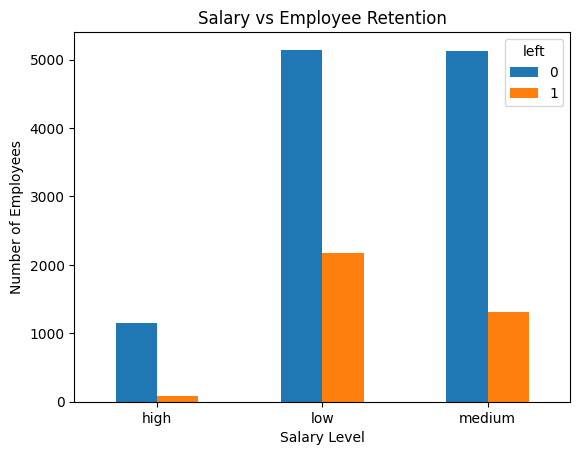

In [ ]:
salary_retention = pd.crosstab(data['salary'], data['left'])

salary_retention.plot(kind='bar')
plt.title('Salary vs Employee Retention')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.show()

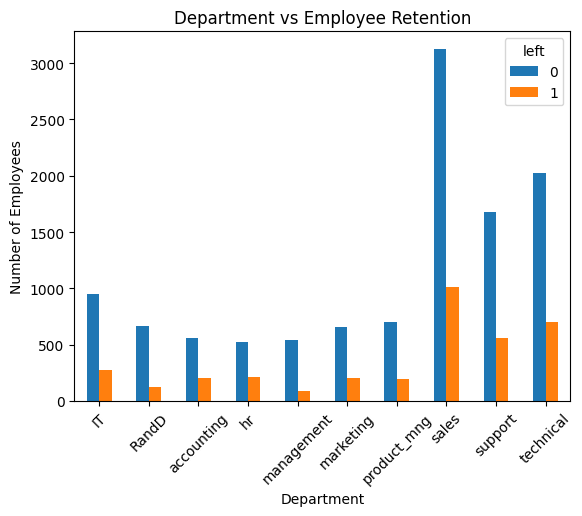

In [ ]:
dept_retention = pd.crosstab(data['Department'], data['left'])

dept_retention.plot(kind='bar')
plt.title('Department vs Employee Retention')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.show()

In [ ]:
le_salary = LabelEncoder()
le_dept = LabelEncoder()

data['salary_encoded'] = le_salary.fit_transform(data['salary'])
data['dept_encoded'] = le_dept.fit_transform(data['Department'])


In [ ]:
features = [
    'satisfaction_level',
    'average_montly_hours',
    'promotion_last_5years',
    'salary_encoded',
    'dept_encoded'
]

X = data[features]
y = data['left']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy*100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 75.96666666666667 %

Confusion Matrix:
[[2113  181]
 [ 540  166]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      2294
           1       0.48      0.24      0.32       706

    accuracy                           0.76      3000
   macro avg       0.64      0.58      0.58      3000
weighted avg       0.72      0.76      0.73      3000

